<a href="https://colab.research.google.com/github/tomasg1997/ds-proyecto-ludopatia/blob/main/ludopatiaEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   bet_id    100000 non-null  object 
 1   user_id   100000 non-null  int64  
 2   bet_type  100000 non-null  object 
 3   sport     100000 non-null  object 
 4   odds      100000 non-null  float64
 5   is_win    100000 non-null  bool   
 6   stake     100000 non-null  float64
 7   gain      100000 non-null  float64
 8   GGR       100000 non-null  float64
dtypes: bool(1), float64(4), int64(1), object(3)
memory usage: 6.2+ MB

--- Estadísticas descriptivas ---


,user_id,odds,stake,gain,GGR
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2495.466980,4.700808,132.631652,119.285792,13.345860
std,1437.932303,4.471646,155.385469,423.864572,399.962988
min,1.000000,1.100000,0.100000,0.000000,-20595.230000
25%,1256.000000,1.320000,25.050000,0.000000,-10.822500
50%,2487.000000,3.180000,84.900000,0.000000,20.300000
75%,3735.000000,6.440000,188.850000,66.262500,115.000000
max,5000.000000,62.150000,1000.000000,21054.330000,999.950000


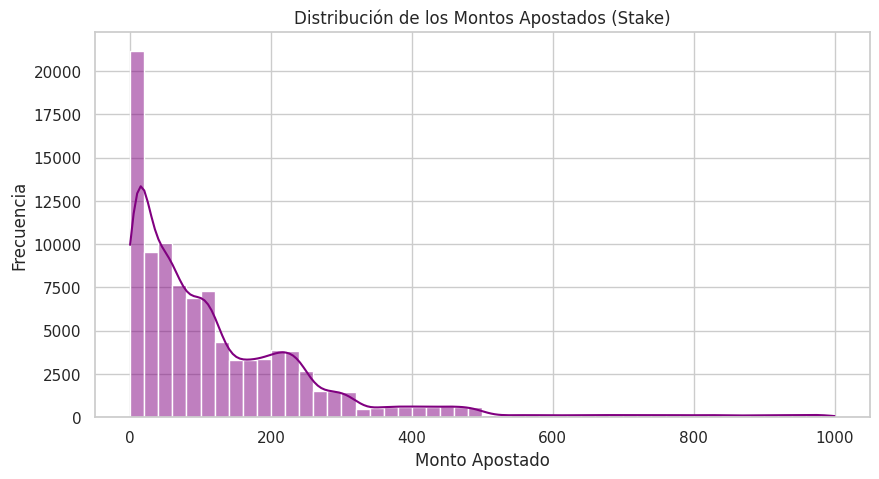

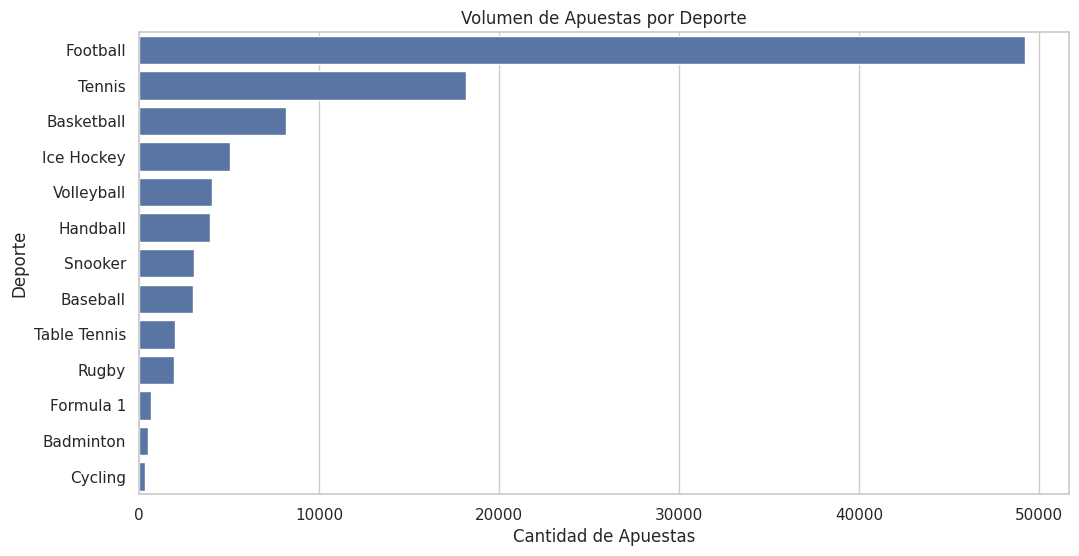

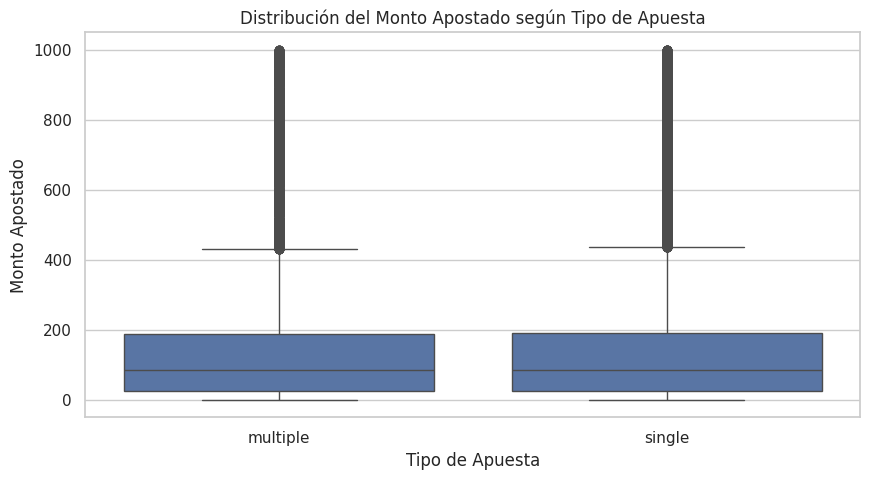


Se eliminaron 4995 registros considerados outliers en 'stake'.
--- Dataset final transformado y listo---


,odds,stake,gain,GGR,sport_encoded,bet_type_encoded,is_win_encoded
0,1.059135,-0.946190,-0.328408,0.009743,7,0,0
1,0.913870,1.459347,-0.328408,0.859678,4,1,0
2,-0.715325,-1.050177,-0.310268,-0.046003,4,1,1
3,-0.704151,0.465577,-0.328408,0.508554,11,1,0
4,-0.722030,2.182647,1.292082,-0.582461,4,1,1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Carga del Dataset
df = pd.read_csv('bets_final.csv')

print("--- Información general del dataset ---")
df.info()

print("\n--- Estadísticas descriptivas ---")
display(df.describe())

# Análisis Exploratorio de Datos (EDA) y Gráficos
sns.set_theme(style="whitegrid")

# Gráfico 1: Distribución de los montos apostados
plt.figure(figsize=(10, 5))
sns.histplot(df['stake'], bins=50, kde=True, color='purple')
plt.title('Distribución de los Montos Apostados (Stake)')
plt.xlabel('Monto Apostado')
plt.ylabel('Frecuencia')
plt.show()

# Gráfico 2: Deportes más populares
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='sport', order=df['sport'].value_counts().index)
plt.title('Volumen de Apuestas por Deporte')
plt.xlabel('Cantidad de Apuestas')
plt.ylabel('Deporte')
plt.show()

# Gráfico 3: Monto apostado según el tipo de apuesta (Simple vs Múltiple)
plt.figure(figsize=(10, 5))
sns.boxplot(x='bet_type', y='stake', data=df)
plt.title('Distribución del Monto Apostado según Tipo de Apuesta')
plt.xlabel('Tipo de Apuesta')
plt.ylabel('Monto Apostado')
plt.show()

# Tratamiento de Valores Faltantes
imputer_num = SimpleImputer(strategy='median')
columnas_num = ['stake', 'odds', 'gain', 'GGR']
df[columnas_num] = imputer_num.fit_transform(df[columnas_num])

# Detección y Tratamiento de Outliers
Q1 = df['stake'].quantile(0.25)
Q3 = df['stake'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtro de apuestas extremas
df_limpio = df[(df['stake'] >= limite_inferior) & (df['stake'] <= limite_superior)].copy()

print(f"\nSe eliminaron {len(df) - len(df_limpio)} registros considerados outliers en 'stake'.")

# Transformación de Datos y Feature Engineering
le = LabelEncoder()
df_limpio['sport_encoded'] = le.fit_transform(df_limpio['sport'])
df_limpio['bet_type_encoded'] = le.fit_transform(df_limpio['bet_type'])
df_limpio['is_win_encoded'] = le.fit_transform(df_limpio['is_win'])

df_modelo = df_limpio.drop(columns=['bet_id', 'user_id', 'sport', 'bet_type', 'is_win'])

# Estandarización y Preparación
scaler = StandardScaler()
columnas_a_escalar = ['stake', 'odds', 'gain', 'GGR']
df_modelo[columnas_a_escalar] = scaler.fit_transform(df_modelo[columnas_a_escalar])

print("--- Dataset final transformado y listo---")
display(df_modelo.head())